# **Parte 1: Diagnóstico**

1. Lectura y documentación inicial: 
    - Carga el dataset en R/Python.
    - ¿Cuántas observaciones y variables hay?
    - ¿Cuántas variables son categóricas y cuántas numéricas?
    - ¿Hay alguna variable que pueda ser un ID?

2. Diagnóstico exploratorio:
    - Describe al menos 2 variables numéricas con media, min y max. 
    - Describe al menos 2 variables categóricas con sus frecuencias.

3. Conclusiones exploratorias:
    - Extrae al menos 5 hallazgos interesantes con visualizaciones que los respalden (usa  tablas cruzadas, ggplot2, tableone, etc.).

### **0: Dependencias**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
from matplotlib import pyplot as plt
from sklearn.impute import KNNImputer


### **1. Lectura y documentación inicial**

##### 1.1: Carga del dataset en Python

In [2]:
# Cargamos los datos del archivo CSV en un DataFrame de pandas
path = "/home/yagoh/Escritorio/Personal/dev/Educacion/Diplomado-Tecnicas-Estadisticas-y-Mineria-de-Datos/Unidad_3/Data/netflix-rotten-tomatoes-metacritic-imdb-netflix-rotten-tomatoes-metacritic-imdb.csv"
df = pd.read_csv(path)

# Vemos las primeras filas
df.head(1)

,Title,Genre,Tags,Languages,Series or Movie,Hidden Gem Score,Country Availability,Runtime,Director,Writer,...,Netflix Release Date,Production House,Netflix Link,IMDb Link,Summary,IMDb Votes,Image,Poster,TMDb Trailer,Trailer Site
0,Lets Fight Ghost,"Crime, Drama, Fantasy, Horror, Romance","Comedy Programmes,Romantic TV Comedies,Horror ...","Swedish, Spanish",Series,4.3,Thailand,< 30 minutes,Tomas Alfredson,John Ajvide Lindqvist,...,2021-03-04,"Canal+, Sandrew Metronome",https://www.netflix.com/watch/81415947,https://www.imdb.com/title/tt1139797,A med student with a supernatural gift tries t...,205926.0,https://occ-0-4708-64.1.nflxso.net/dnm/api/v6/...,https://m.media-amazon.com/images/M/MV5BOWM4NT...,NaN,NaN


##### 1.2: ¿Cuántas observaciones y variables hay?

In [3]:
observaciones, variables = df.shape

print(f"El dataset tiene {observaciones} observaciones y {variables} variables.")

El dataset tiene 15480 observaciones y 29 variables.


##### 1.3: ¿Cuántas variables son categóricas y cuántas numéricas?

In [4]:
# Podemos hacer una primera exploración usando .describe(), ya que nos da un resumen estadístico de las variables numéricas del DataFrame.
df.describe()

,Hidden Gem Score,IMDb Score,Rotten Tomatoes Score,Metacritic Score,Awards Received,Awards Nominated For,IMDb Votes
count,13379.000000,13381.000000,6382.000000,4336.000000,6075.000000,7661.000000,1.337900e+04
mean,5.937551,6.496054,59.523034,56.813653,8.764444,13.983161,4.272841e+04
std,2.250202,1.146910,26.999173,17.582545,18.311171,29.821052,1.257012e+05
min,0.600000,1.000000,0.000000,5.000000,1.000000,1.000000,5.000000e+00
25%,3.800000,5.800000,38.000000,44.000000,1.000000,2.000000,4.035000e+02
50%,6.800000,6.600000,64.000000,57.000000,3.000000,5.000000,2.322000e+03
75%,7.900000,7.300000,83.000000,70.000000,8.000000,12.000000,2.089050e+04
max,9.800000,9.700000,100.000000,100.000000,300.000000,386.000000,2.354197e+06


In [5]:
# Veamos si estas columnas en verdad son numéricas.

df[["Hidden Gem Score", "IMDb Score", "Rotten Tomatoes Score", "Metacritic Score", "Awards Received", "Awards Nominated For", "IMDb Votes"]]

,Hidden Gem Score,IMDb Score,Rotten Tomatoes Score,Metacritic Score,Awards Received,Awards Nominated For,IMDb Votes
0,4.3,7.9,98.0,82.0,74.0,57.0,205926.0
1,7.0,5.8,79.0,69.0,1.0,NaN,2838.0
2,6.4,4.3,NaN,46.0,NaN,NaN,1720.0
3,7.7,6.5,NaN,NaN,1.0,NaN,1147.0
4,8.1,6.3,NaN,NaN,NaN,4.0,63.0
...,...,...,...,...,...,...,...
15475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15477,8.4,6.8,NaN,NaN,NaN,NaN,71.0
15478,8.2,6.4,NaN,NaN,NaN,NaN,82.0


In [6]:
# En efecto, son variables numéricas, pero esto no nos garantiza que no haya otras variables que sean numéricas pero que no estén en el formato correcto.

columnas = df.columns

for columna in columnas:
    print(50*"=")
    print(f"Columna: {columna}")
    print(f"Valor: {df[df[columna].notna()][columna][:1]}")
    print(f"Tipo de dato: {type(df[columna][0])}")
    print(50*"=")

Columna: Title
Valor: 0    Lets Fight Ghost
Name: Title, dtype: str
Tipo de dato: <class 'str'>
Columna: Genre
Valor: 0    Crime, Drama, Fantasy, Horror, Romance
Name: Genre, dtype: str
Tipo de dato: <class 'str'>
Columna: Tags
Valor: 0    Comedy Programmes,Romantic TV Comedies,Horror ...
Name: Tags, dtype: str
Tipo de dato: <class 'str'>
Columna: Languages
Valor: 0    Swedish, Spanish
Name: Languages, dtype: str
Tipo de dato: <class 'str'>
Columna: Series or Movie
Valor: 0    Series
Name: Series or Movie, dtype: str
Tipo de dato: <class 'str'>
Columna: Hidden Gem Score
Valor: 0    4.3
Name: Hidden Gem Score, dtype: float64
Tipo de dato: <class 'numpy.float64'>
Columna: Country Availability
Valor: 0    Thailand
Name: Country Availability, dtype: str
Tipo de dato: <class 'str'>
Columna: Runtime
Valor: 0    < 30 minutes
Name: Runtime, dtype: str
Tipo de dato: <class 'str'>
Columna: Director
Valor: 0    Tomas Alfredson
Name: Director, dtype: str
Tipo de dato: <class 'str'>
Columna: Writer

In [7]:
# Vemos que la variable Boxoffice, que es numérica, no está en el formato correcto. Esto se debe a que tiene un símbolo de dólar y una coma, lo que hace que pandas la lea como un objeto (string) en lugar de un número.

df["Boxoffice"] = df["Boxoffice"].str.replace("$", "").str.replace(",", "").astype(float)
df["Boxoffice"].head(1)

0    2122065.0
Name: Boxoffice, dtype: float64

In [8]:
# Una vez corregido, ya tenemos todas las variables numéricas.
universo = set(df.columns)
numericas = set(df.describe().columns)
categoricas = universo - numericas

print(f"Variables numéricas:\n{numericas} \n\nVariables categóricas:\n{categoricas}")

Variables numéricas:
{'Metacritic Score', 'IMDb Score', 'Awards Received', 'Boxoffice', 'Hidden Gem Score', 'Awards Nominated For', 'Rotten Tomatoes Score', 'IMDb Votes'} 

Variables categóricas:
{'Languages', 'Genre', 'IMDb Link', 'Country Availability', 'Trailer Site', 'Director', 'Actors', 'View Rating', 'Image', 'Production House', 'Title', 'Poster', 'Tags', 'TMDb Trailer', 'Netflix Link', 'Summary', 'Release Date', 'Series or Movie', 'Netflix Release Date', 'Runtime', 'Writer'}


##### 1.4. ¿Hay alguna variable que pueda ser un ID?

In [9]:
# Propongo que la variable "Title" sea nuestro id, vamos a comprobarlo.

print(f"Cantidad de títulos: {df['Title'].nunique()}")

Cantidad de títulos: 15071


In [10]:
df["Title"].isnull().sum()

np.int64(0)

In [11]:
# Si hay nombres repetidos, entonces no podemos usar esta variable como id.

# Veremos si hay alguna columna que no tenga repetidos ni nulos, y que por lo tanto pueda ser nuestro id.
for col in df.columns:
    if df[col].isnull().sum() == 0 and df[col].nunique() == len(df):
        print(f"La columna {col} puede ser nuestro id.")

La columna Netflix Link puede ser nuestro id.


### **2. Diagnóstico exploratorio**

##### 2.1: Describe al menos 2 variables numéricas con media, min y max.

In [12]:
# Voy a escoger las variables Boxoffice y IMDb Score

df[["Boxoffice", "IMDb Score"]].describe().loc[["mean", "min", "max"]].style.format('{:,.2f}')

,Boxoffice,IMDb Score
mean,"45,682,292.02",6.50
min,72.00,1.00
max,"659,363,944.00",9.70


##### 2.2: Describe al menos 2 variables categóricas con sus frecuencias.

In [13]:
df[["Genre", "Languages"]].describe()

,Genre,Languages
count,13770,13526
unique,1780,1437
top,Comedy,English
freq,1186,5133


### **3. Conclusiones exploratorias**

##### 3.1 Extrae al menos 5 hallazgos interesantes con visualizaciones que los respalden.

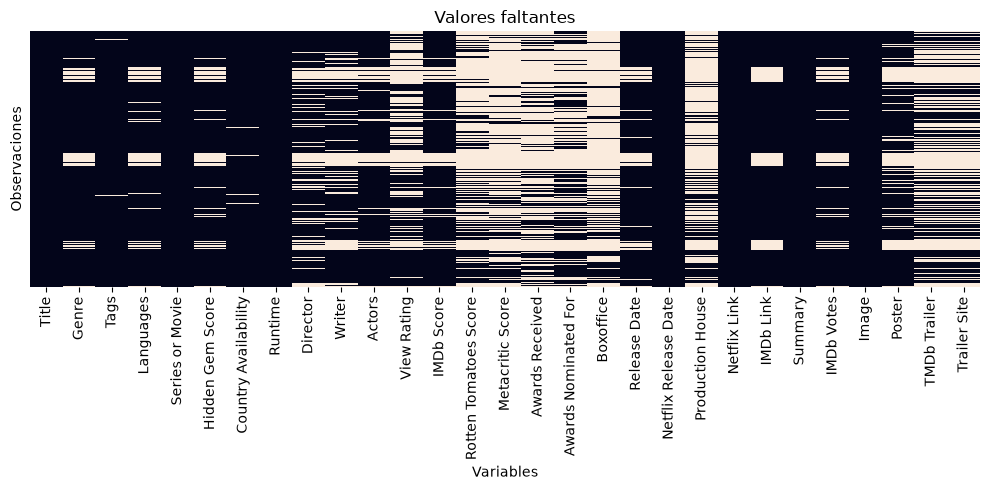

In [ ]:
# Basandome en su ejemplo profe, quiero ver la cantidad de valores faltantes en el dataset, para ver si es necesario hacer un tratamiento de datos faltantes.

plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isna(),
    cbar=False,
    yticklabels=False
)

plt.title("Valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Observaciones")

plt.tight_layout()
plt.show()

In [36]:
# Hay varias variables que tienen demasiados valores faltantes, por lo que es necesario hacer un tratamiento de datos faltantes.

faltantes = (
    df.isnull().sum(),
    df.isnull().sum() / len(df) * 100
)
faltantes = pd.DataFrame(faltantes).T
faltantes.columns = ["Valores faltantes", "Porcentaje"]
faltantes = faltantes.sort_values(by="Porcentaje", ascending=True)
faltantes = faltantes[faltantes["Valores faltantes"] > 0]
faltantes


,Valores faltantes,Porcentaje
Runtime,1.0,0.006460
Summary,9.0,0.058140
Country Availability,19.0,0.122739
Tags,67.0,0.432817
Genre,1710.0,11.046512
Actors,1925.0,12.435401
Languages,1954.0,12.622739
IMDb Score,2099.0,13.559432
Hidden Gem Score,2101.0,13.572351
IMDb Votes,2101.0,13.572351


In [60]:
# Vamos a clasificar por rangos
alto = faltantes[faltantes["Porcentaje"] > 20]
medio = faltantes[(faltantes["Porcentaje"] > 5) & (faltantes["Porcentaje"] <= 20)]
bajo = faltantes[faltantes["Porcentaje"] <= 5]

print(f"Variables con alto porcentaje de valores faltantes --Eliminación directa-- (>20%):\n{alto['Porcentaje']}\n")
print(f"Variables con medio porcentaje de valores faltantes --Imputación-- (5%-20%):\n{medio['Porcentaje']}\n")
print(f"Variables con bajo porcentaje de valores faltantes --Imputación-- (<=5%):\n{bajo['Porcentaje']}\n")

Variables con alto porcentaje de valores faltantes --Eliminación directa-- (>20%):
Poster                   23.501292
Writer                   27.971576
Director                 30.413437
View Rating              45.374677
Awards Nominated For     50.510336
Trailer Site             53.527132
TMDb Trailer             53.527132
Rotten Tomatoes Score    58.772610
Awards Received          60.755814
Production House         66.737726
Metacritic Score         71.989664
Boxoffice                74.114987
Name: Porcentaje, dtype: float64

Variables con medio porcentaje de valores faltantes --Imputación-- (5%-20%):
Genre               11.046512
Actors              12.435401
Languages           12.622739
IMDb Score          13.559432
Hidden Gem Score    13.572351
IMDb Votes          13.572351
Release Date        13.611111
IMDb Link           14.877261
Name: Porcentaje, dtype: float64

Variables con bajo porcentaje de valores faltantes --Imputación-- (<=5%):
Runtime                 0.006460
Summa

In [81]:
faltantes.T[:100]

,Runtime,Summary,Country Availability,Tags,Genre,Actors,Languages,IMDb Score,Hidden Gem Score,IMDb Votes,...,Director,View Rating,Awards Nominated For,Trailer Site,TMDb Trailer,Rotten Tomatoes Score,Awards Received,Production House,Metacritic Score,Boxoffice
Valores faltantes,1.00000,9.00000,19.000000,67.000000,1710.000000,1925.000000,1954.000000,2099.000000,2101.000000,2101.000000,...,4708.000000,7024.000000,7819.000000,8286.000000,8286.000000,9098.00000,9405.000000,10331.000000,11144.000000,11473.000000
Porcentaje,0.00646,0.05814,0.122739,0.432817,11.046512,12.435401,12.622739,13.559432,13.572351,13.572351,...,30.413437,45.374677,50.510336,53.527132,53.527132,58.77261,60.755814,66.737726,71.989664,74.114987


In [37]:
numericas

{'Awards Nominated For',
 'Awards Received',
 'Boxoffice',
 'Hidden Gem Score',
 'IMDb Score',
 'IMDb Votes',
 'Metacritic Score',
 'Rotten Tomatoes Score'}